In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass, asdict, field
from typing import List, Tuple
import math
import os

os.makedirs('result', exist_ok=True)
np.random.seed(42)

In [52]:
@dataclass
class DevelopConfig:
    # A-S model parameters
    T: float = 1.0
    sigma: float = 2.0
    dt: float = 0.005
    n_steps: int = 200
    gamma: float = 0.1
    A: float = 140.0
    k: float = 1.5
    q0: int = 0

    # Stock GBM parameters
    S_stock_0: float = 800.0
    drift: float = 0.0           # % 단위. 15 → 시뮬레이션 동안 +15% 상승
    sigma_stock: float = 10.0

    # BSM parameters (fixed during simulation)
    K: float = 800.0
    r: float = 0.03
    T_option: float = 0.082      # ~30 days in years
    sigma_bsm: float = 0.2       # sigma_stock과 일치 (10/800*sqrt(252) ≈ 0.2)

    # Develop extensions
    n_levels: int = 3
    tick_size: float = 0.05
    buckets: List[Tuple[float, float]] = field(default_factory=lambda: [
        (0.02, 1.0),
        (0.05, 1.5),
        (0.10, 2.5),
        (float('inf'), 3.5)
    ])

config = DevelopConfig(drift=10)

In [53]:
# === BSM functions ===

def norm_cdf(x):
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))

def bsm_call_price(S, K, T, r, sigma):
    if T <= 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * norm_cdf(d1) - K * math.exp(-r * T) * norm_cdf(d2)

def bsm_delta(S, K, T, r, sigma):
    if T <= 0:
        return 1.0 if S > K else 0.0
    d1 = (math.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * math.sqrt(T))
    return norm_cdf(d1)

# === Path generation ===

def generate_stock_path(config: DevelopConfig) -> np.ndarray:
    Z = np.random.randn(config.n_steps)
    drift_abs = config.S_stock_0 * config.drift / 100
    increments = drift_abs * config.dt + config.sigma_stock * np.sqrt(config.dt) * Z
    prices = np.zeros(config.n_steps + 1)
    prices[0] = config.S_stock_0
    prices[1:] = config.S_stock_0 + np.cumsum(increments)
    return prices

def generate_option_path(stock_prices: np.ndarray, config: DevelopConfig):
    option_prices = np.array([
        bsm_call_price(S, config.K, config.T_option, config.r, config.sigma_bsm)
        for S in stock_prices
    ])
    deltas = np.array([
        bsm_delta(S, config.K, config.T_option, config.r, config.sigma_bsm)
        for S in stock_prices
    ])
    return option_prices, deltas

# === A-S model functions ===

def compute_reservation_price(s: float, net_delta: float, t: float, config) -> float:
    tau = config.T - t
    return s - net_delta * config.gamma * (config.sigma ** 2) * tau

def compute_optimal_spread(t: float, config) -> float:
    tau = config.T - t
    return config.gamma * (config.sigma ** 2) * tau + (2 / config.gamma) * np.log(1 + config.gamma / config.k)

def tick_floor(price: float, tick_size: float) -> float:
    return np.floor(price / tick_size) * tick_size

def tick_ceil(price: float, tick_size: float) -> float:
    return np.ceil(price / tick_size) * tick_size

def compute_quotes(s: float, net_delta: float, t: float, config: DevelopConfig) -> Tuple[float, float]:
    r = compute_reservation_price(s, net_delta, t, config)
    spread = compute_optimal_spread(t, config)
    bid_raw = r - spread / 2
    ask_raw = r + spread / 2
    bid = tick_floor(bid_raw, config.tick_size)
    ask = tick_ceil(ask_raw, config.tick_size)
    return bid, ask

# === Fill probability ===

def get_fill_multiplier(price_change_pct: float, config: DevelopConfig) -> float:
    abs_change = abs(price_change_pct)
    for threshold, multiplier in config.buckets:
        if abs_change < threshold:
            return multiplier
    return config.buckets[-1][1]

def compute_fill_probability_develop(delta: float, stock_prev: float, stock_current: float,
                                      is_bid: bool, config: DevelopConfig) -> float:
    """체결 확률 계산. bucket 승수는 t-1→t 주가 변동률 기준 (look-ahead 없음)"""
    if delta <= 0:
        return 1.0

    base_intensity = config.A * np.exp(-config.k * delta)
    base_prob = min(base_intensity * config.dt, 1.0)

    stock_change_pct = (stock_current - stock_prev) / stock_prev * 100
    multiplier = get_fill_multiplier(stock_change_pct, config)

    if stock_change_pct > 0:  # stock up → ask fill more likely
        if not is_bid:
            return min(base_prob * multiplier, 1.0)
        else:
            return max(base_prob / multiplier, 0.0)
    elif stock_change_pct < 0:  # stock down → bid fill more likely
        if is_bid:
            return min(base_prob * multiplier, 1.0)
        else:
            return max(base_prob / multiplier, 0.0)
    else:
        return base_prob

In [54]:
@dataclass
class SimulationState:
    step: int
    time: float
    mid_price: float
    inventory: int
    cash: float
    reservation_price: float
    spread: float
    bid: float
    ask: float
    bid_fill: int
    ask_fill: int
    stock_price: float = 0.0
    option_delta: float = 0.0
    net_delta: float = 0.0
    bid_prob: float = 0.0
    ask_prob: float = 0.0
    price_change_pct: float = 0.0
    multiplier: float = 1.0
    bid_fill_price: float = 0.0
    ask_fill_price: float = 0.0
    bid_levels_detail: str = ""
    ask_levels_detail: str = ""


def run_develop_simulation(config: DevelopConfig, stock_prices: np.ndarray = None) -> List[SimulationState]:
    if stock_prices is None:
        stock_prices = generate_stock_path(config)

    option_prices, deltas = generate_option_path(stock_prices, config)

    inventory = config.q0
    cash = 0.0
    history = []

    # step 0: 호가만 설정, 체결 없음
    s0 = option_prices[0]
    s_stock0 = stock_prices[0]
    delta_0 = deltas[0]
    net_delta_0 = inventory * delta_0
    bid_prev, ask_prev = compute_quotes(s0, net_delta_0, 0.0, config)
    bid_levels_prev = [bid_prev - i * config.tick_size for i in range(config.n_levels)]
    ask_levels_prev = [ask_prev + i * config.tick_size for i in range(config.n_levels)]
    r0 = compute_reservation_price(s0, net_delta_0, 0.0, config)
    spread0 = compute_optimal_spread(0.0, config)

    state0 = SimulationState(
        0, 0.0, s0, inventory, cash, r0, spread0, bid_prev, ask_prev,
        0, 0,
        stock_price=s_stock0, option_delta=delta_0, net_delta=net_delta_0
    )
    history.append(state0)

    # step 1 ~ n_steps-1: t-1 호가를 t시점 mid price로 체결 판정
    for step in range(1, config.n_steps):
        t = step * config.dt
        s = option_prices[step]
        s_stock = stock_prices[step]
        s_stock_prev = stock_prices[step - 1]
        delta_t = deltas[step]
        net_delta_val = inventory * delta_t

        # t-1에서 깔아놓은 호가와 t시점 mid price 간 거리로 체결 판정
        bid_fills_raw = []
        ask_fills_raw = []
        bid_probs = []
        ask_probs = []

        for i in range(config.n_levels):
            delta_bid_i = s - bid_levels_prev[i]
            delta_ask_i = ask_levels_prev[i] - s

            prob_bid_i = compute_fill_probability_develop(
                delta_bid_i, s_stock_prev, s_stock, True, config)
            prob_ask_i = compute_fill_probability_develop(
                delta_ask_i, s_stock_prev, s_stock, False, config)

            bid_fills_raw.append(np.random.random() < prob_bid_i)
            ask_fills_raw.append(np.random.random() < prob_ask_i)
            bid_probs.append(prob_bid_i)
            ask_probs.append(prob_ask_i)

        # sweep 보정
        bid_fills = list(bid_fills_raw)
        ask_fills = list(ask_fills_raw)
        for i in range(config.n_levels - 1, 0, -1):
            if bid_fills[i]:
                bid_fills[i-1] = True
        for i in range(config.n_levels - 1, 0, -1):
            if ask_fills[i]:
                ask_fills[i-1] = True

        # 체결 가격: delta <= 0 이면 mid price(t시점), 아니면 호가 가격(t-1에서 설정한)
        total_bid_cost = 0.0
        total_ask_revenue = 0.0
        bid_fill_count = 0
        ask_fill_count = 0

        for i in range(config.n_levels):
            if bid_fills[i]:
                delta_bid_i = s - bid_levels_prev[i]
                fill_price = s if delta_bid_i <= 0 else bid_levels_prev[i]
                total_bid_cost += fill_price
                bid_fill_count += 1
            if ask_fills[i]:
                delta_ask_i = ask_levels_prev[i] - s
                fill_price = s if delta_ask_i <= 0 else ask_levels_prev[i]
                total_ask_revenue += fill_price
                ask_fill_count += 1

        stock_change_pct = (s_stock - s_stock_prev) / s_stock_prev * 100
        multiplier = get_fill_multiplier(stock_change_pct, config)

        bid_detail = ",".join(["1" if f else "0" for f in bid_fills])
        ask_detail = ",".join(["1" if f else "0" for f in ask_fills])

        # 체결 반영
        inventory += bid_fill_count
        inventory -= ask_fill_count
        cash -= total_bid_cost
        cash += total_ask_revenue

        # t시점 정보로 새 호가 설정 (t+1에서 체결될 호가)
        net_delta_after = inventory * delta_t
        bid_new, ask_new = compute_quotes(s, net_delta_after, t, config)
        bid_levels_prev = [bid_new - i * config.tick_size for i in range(config.n_levels)]
        ask_levels_prev = [ask_new + i * config.tick_size for i in range(config.n_levels)]

        r = compute_reservation_price(s, net_delta_after, t, config)
        spread = compute_optimal_spread(t, config)

        state = SimulationState(
            step, t, s, inventory, cash, r, spread, bid_new, ask_new,
            bid_fill_count, ask_fill_count,
            stock_price=s_stock, option_delta=delta_t, net_delta=net_delta_after,
            bid_prob=bid_probs[0], ask_prob=ask_probs[0],
            price_change_pct=stock_change_pct, multiplier=multiplier,
            bid_fill_price=total_bid_cost, ask_fill_price=total_ask_revenue,
            bid_levels_detail=bid_detail, ask_levels_detail=ask_detail
        )
        history.append(state)

    # final state
    final_s = option_prices[-1]
    final_stock = stock_prices[-1]
    final_delta = deltas[-1]
    final_state = SimulationState(
        config.n_steps, config.T, final_s, inventory, cash,
        final_s, 0, final_s, final_s,
        0, 0,
        stock_price=final_stock, option_delta=final_delta,
        net_delta=inventory * final_delta
    )
    history.append(final_state)
    return history

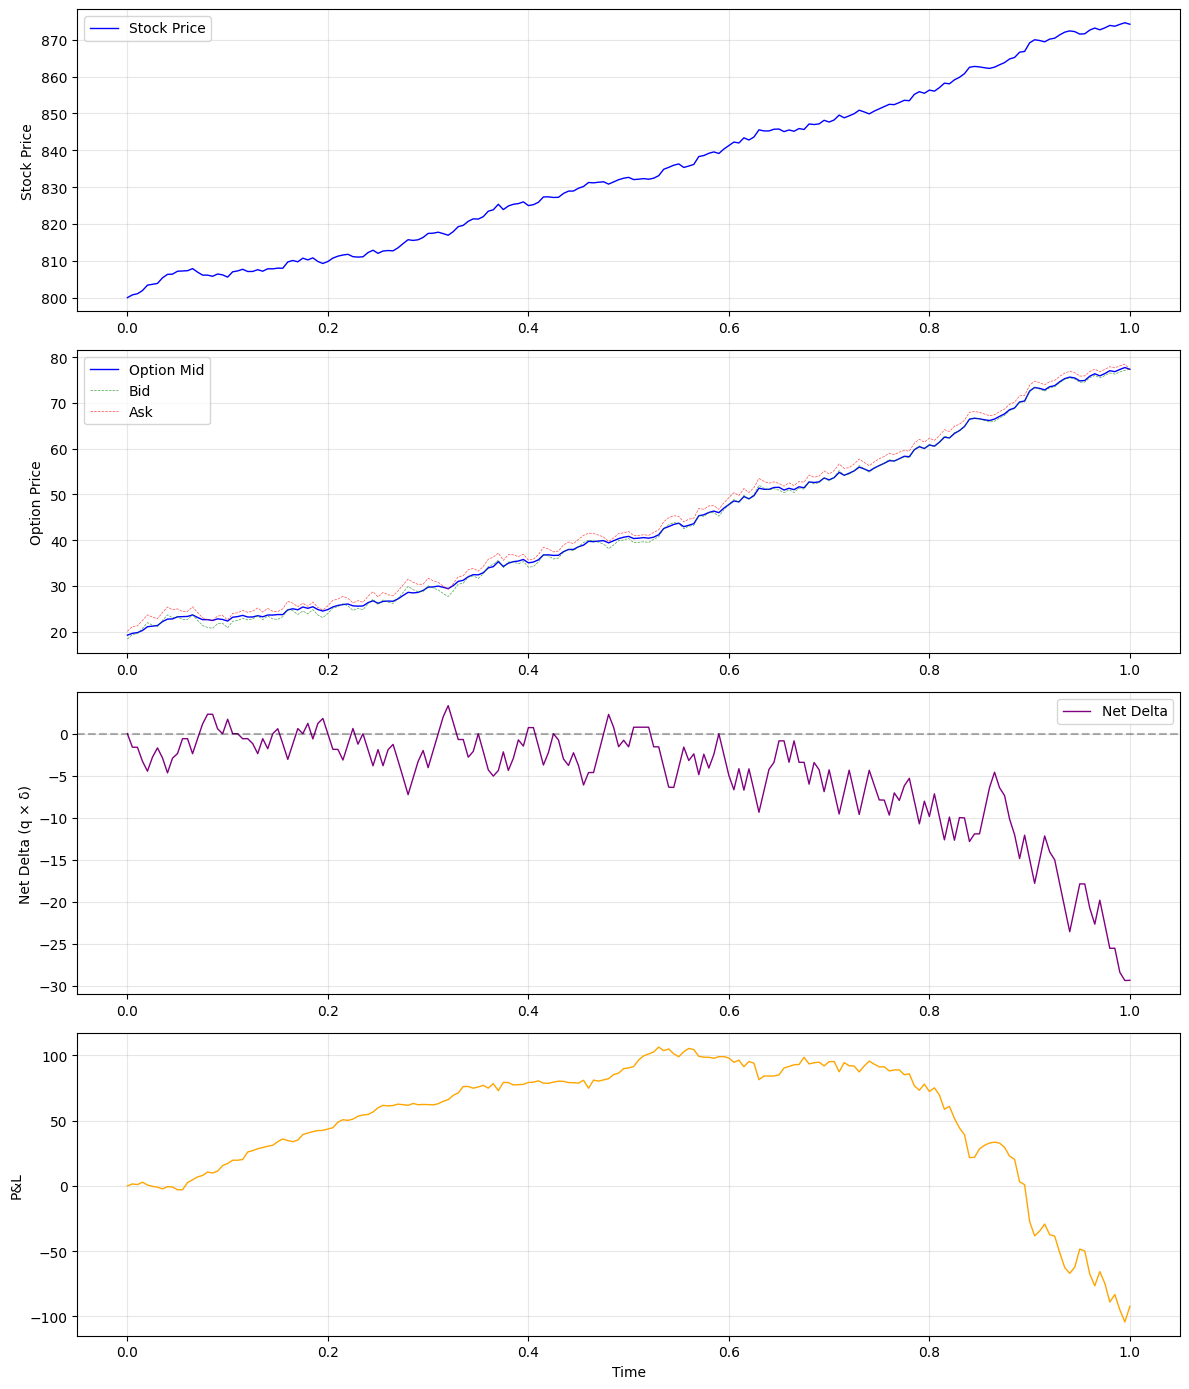

Initial option price: 19.25, Final: 77.33
Stock: 800 -> 874.23
Delta: 0.5285 -> 0.9475
Final Inventory: -31, Net Delta: -29.37
Cash: 2305.00, P&L: -92.28


In [55]:
np.random.seed(42)
stock_prices = generate_stock_path(config)
history = run_develop_simulation(config, stock_prices)

times = [s.time for s in history]
mid_price_hist = [s.mid_price for s in history]
bid_hist = [s.bid for s in history]
ask_hist = [s.ask for s in history]
stock_hist = [s.stock_price for s in history]
delta_hist = [s.option_delta for s in history]
net_delta_hist = [s.net_delta for s in history]
inventory_hist = [s.inventory for s in history]
cash_hist = [s.cash for s in history]
pnl = [cash_hist[i] + inventory_hist[i] * mid_price_hist[i] for i in range(len(history))]

df = pd.DataFrame([asdict(s) for s in history])
df['pnl'] = pnl
df.to_csv('result/develop_simulation_history.csv', index=False)

fig, axes = plt.subplots(4, 1, figsize=(12, 14))

axes[0].plot(times, stock_hist, 'b-', label='Stock Price', linewidth=1)
axes[0].set_ylabel('Stock Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, mid_price_hist, 'b-', label='Option Mid', linewidth=1)
axes[1].plot(times, bid_hist, 'g--', label='Bid', alpha=0.7, linewidth=0.5)
axes[1].plot(times, ask_hist, 'r--', label='Ask', alpha=0.7, linewidth=0.5)
axes[1].set_ylabel('Option Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(times, net_delta_hist, 'purple', label='Net Delta', linewidth=1)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[2].set_ylabel('Net Delta (q × δ)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(times, pnl, 'orange', linewidth=1)
axes[3].set_xlabel('Time')
axes[3].set_ylabel('P&L')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('result/develop_single_simulation.png', dpi=150)
plt.show()

final = history[-1]
print(f"Initial option price: {history[0].mid_price:.2f}, Final: {final.mid_price:.2f}")
print(f"Stock: {config.S_stock_0:.0f} -> {final.stock_price:.2f}")
print(f"Delta: {history[0].option_delta:.4f} -> {final.option_delta:.4f}")
print(f"Final Inventory: {final.inventory}, Net Delta: {final.net_delta:.2f}")
print(f"Cash: {final.cash:.2f}, P&L: {pnl[-1]:.2f}")

In [56]:
immediate_fills = sum(1 for s in history[:-1] if s.bid_prob == 1.0 or s.ask_prob == 1.0)
multiplier_applied = sum(1 for s in history[:-1] if s.multiplier > 1.0)
total_bid_fills = sum(s.bid_fill for s in history[:-1])
total_ask_fills = sum(s.ask_fill for s in history[:-1])

print(f"=== Develop Mode Statistics ===")
print(f"n_levels={config.n_levels}, tick_size={config.tick_size}")
print(f"BSM: K={config.K}, T_option={config.T_option:.3f}, sigma_bsm={config.sigma_bsm}")
print(f"Total steps: {config.n_steps}")
print(f"Immediate fills (delta <= 0, level 0): {immediate_fills}")
print(f"Steps with multiplier > 1.0: {multiplier_applied}")
print(f"Total bid fills: {total_bid_fills} ({total_bid_fills/config.n_steps:.2f} per step)")
print(f"Total ask fills: {total_ask_fills} ({total_ask_fills/config.n_steps:.2f} per step)")
print(f"\nBucket distribution (stock price change):")
for threshold, mult in config.buckets:
    count = sum(1 for s in history[:-1] if get_fill_multiplier(s.price_change_pct, config) == mult)
    print(f"  multiplier {mult}: {count} steps")

=== Develop Mode Statistics ===
n_levels=3, tick_size=0.05
BSM: K=800.0, T_option=0.082, sigma_bsm=0.2
Total steps: 200
Immediate fills (delta <= 0, level 0): 93
Steps with multiplier > 1.0: 172
Total bid fills: 274 (1.37 per step)
Total ask fills: 305 (1.52 per step)

Bucket distribution (stock price change):
  multiplier 1.0: 28 steps
  multiplier 1.5: 48 steps
  multiplier 2.5: 72 steps
  multiplier 3.5: 52 steps


In [57]:
def run_multiple_develop_simulations(config: DevelopConfig, n_simulations: int = 1000):
    results = {'final_pnl': [], 'final_inventory': [], 'final_net_delta': [], 'immediate_fills': []}

    for _ in range(n_simulations):
        stock_prices = generate_stock_path(config)
        history = run_develop_simulation(config, stock_prices)
        final = history[-1]
        results['final_pnl'].append(final.cash + final.inventory * final.mid_price)
        results['final_inventory'].append(final.inventory)
        results['final_net_delta'].append(final.net_delta)
        results['immediate_fills'].append(sum(1 for s in history[:-1] if s.bid_prob == 1.0 or s.ask_prob == 1.0))

    return results

print("Running 1000 Develop simulations...")
np.random.seed(42)
develop_results = run_multiple_develop_simulations(config, 1000)

print(f"\n=== Develop Mode Results (1000 simulations) ===")
print(f"P&L: mean = {np.mean(develop_results['final_pnl']):.1f}, std = {np.std(develop_results['final_pnl']):.1f}")
print(f"Final Inventory: mean = {np.mean(develop_results['final_inventory']):.2f}, std = {np.std(develop_results['final_inventory']):.1f}")
print(f"Final Net Delta: mean = {np.mean(develop_results['final_net_delta']):.2f}, std = {np.std(develop_results['final_net_delta']):.1f}")
print(f"Immediate fills per sim: mean = {np.mean(develop_results['immediate_fills']):.1f}")

Running 1000 Develop simulations...

=== Develop Mode Results (1000 simulations) ===
P&L: mean = -179.4, std = 141.9
Final Inventory: mean = -25.28, std = 9.5
Final Net Delta: mean = -24.21, std = 9.2
Immediate fills per sim: mean = 97.2


In [58]:
from dataclasses import dataclass as paper_dataclass

@paper_dataclass
class PaperConfig:
    S0: float = 100.0
    T: float = 1.0
    sigma: float = 2.0
    drift: float = 15.0          # % 단위. Develop과 동일 기준
    dt: float = 0.005
    n_steps: int = 200
    gamma: float = 0.1
    A: float = 140.0
    k: float = 1.5
    q0: int = 0

def generate_mid_price_path(config: PaperConfig) -> np.ndarray:
    Z = np.random.randn(config.n_steps)
    drift_abs = config.S0 * config.drift / 100
    increments = drift_abs * config.dt + config.sigma * np.sqrt(config.dt) * Z
    prices = np.zeros(config.n_steps + 1)
    prices[0] = config.S0
    prices[1:] = config.S0 + np.cumsum(increments)
    return prices

def compute_fill_probability_paper(delta: float, config: PaperConfig) -> float:
    intensity = config.A * np.exp(-config.k * delta)
    return min(intensity * config.dt, 1.0)

def run_paper_simulation(config: PaperConfig, mid_prices: np.ndarray) -> List[SimulationState]:
    inventory = config.q0
    cash = 0.0
    history = []

    for step in range(config.n_steps):
        t = step * config.dt
        s = mid_prices[step]

        r = compute_reservation_price(s, inventory, t, config)
        spread = compute_optimal_spread(t, config)
        bid = r - spread / 2
        ask = r + spread / 2

        delta_bid = s - bid
        delta_ask = ask - s

        prob_bid = compute_fill_probability_paper(delta_bid, config)
        prob_ask = compute_fill_probability_paper(delta_ask, config)

        bid_fill = np.random.random() < prob_bid
        ask_fill = np.random.random() < prob_ask

        state = SimulationState(step, t, s, inventory, cash, r, spread, bid, ask,
                                bid_fill, ask_fill, bid_prob=prob_bid, ask_prob=prob_ask)
        history.append(state)

        if bid_fill:
            inventory += 1
            cash -= bid
        if ask_fill:
            inventory -= 1
            cash += ask

    final_state = SimulationState(config.n_steps, config.T, mid_prices[-1], inventory, cash,
                                   mid_prices[-1], 0, mid_prices[-1], mid_prices[-1],
                                   0, 0)
    history.append(final_state)
    return history

def run_multiple_paper_simulations(config: PaperConfig, n_simulations: int = 1000):
    results = {'final_pnl': [], 'final_inventory': []}

    for _ in range(n_simulations):
        mid_prices = generate_mid_price_path(config)
        history = run_paper_simulation(config, mid_prices)
        final = history[-1]
        results['final_pnl'].append(final.cash + final.inventory * final.mid_price)
        results['final_inventory'].append(final.inventory)

    return results

In [59]:
print("Comparing Paper vs Develop mode...")
print("Note: Paper trades stock (~100pt), Develop trades option (~19pt via BSM)")
paper_config = PaperConfig()

np.random.seed(42)
paper_results = run_multiple_paper_simulations(paper_config, 1000)
np.random.seed(42)
develop_results = run_multiple_develop_simulations(config, 1000)

print(f"\n{'Mode':<12} {'P&L Mean':<12} {'P&L Std':<12} {'Inv Mean':<12} {'Inv Std':<12}")
print("-" * 60)
print(f"{'Paper':<12} {np.mean(paper_results['final_pnl']):<12.1f} {np.std(paper_results['final_pnl']):<12.1f} {np.mean(paper_results['final_inventory']):<12.2f} {np.std(paper_results['final_inventory']):<12.1f}")
print(f"{'Develop':<12} {np.mean(develop_results['final_pnl']):<12.1f} {np.std(develop_results['final_pnl']):<12.1f} {np.mean(develop_results['final_inventory']):<12.2f} {np.std(develop_results['final_inventory']):<12.1f}")
print(f"{'Dev NetΔ':<12} {'':12s} {'':12s} {np.mean(develop_results['final_net_delta']):<12.2f} {np.std(develop_results['final_net_delta']):<12.1f}")

Comparing Paper vs Develop mode...
Note: Paper trades stock (~100pt), Develop trades option (~19pt via BSM)

Mode         P&L Mean     P&L Std      Inv Mean     Inv Std     
------------------------------------------------------------
Paper        64.7         9.2          -0.06        3.1         
Develop      -179.4       141.9        -25.28       9.5         
Dev NetΔ                               -24.21       9.2         


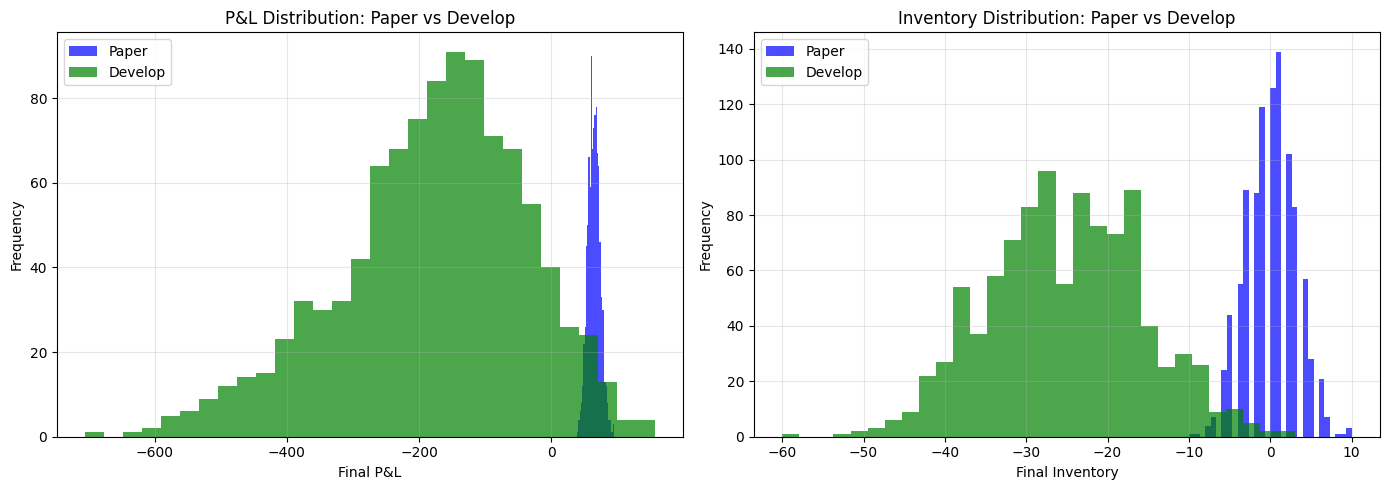

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(paper_results['final_pnl'], bins=30, alpha=0.7, label='Paper', color='blue')
axes[0].hist(develop_results['final_pnl'], bins=30, alpha=0.7, label='Develop', color='green')
axes[0].set_xlabel('Final P&L')
axes[0].set_ylabel('Frequency')
axes[0].set_title('P&L Distribution: Paper vs Develop')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(paper_results['final_inventory'], bins=30, alpha=0.7, label='Paper', color='blue')
axes[1].hist(develop_results['final_inventory'], bins=30, alpha=0.7, label='Develop', color='green')
axes[1].set_xlabel('Final Inventory')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Inventory Distribution: Paper vs Develop')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('result/paper_vs_develop_comparison.png', dpi=150)
plt.show()